In [3]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm


In [4]:
# Load the Updated CSV
CSV_FILE = "GloFASv5_stations_metadata_calfunction_KGE_JSD_20March2026_final.csv"
glofas5_results = pd.read_csv(CSV_FILE)

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    glofas5_results,
    geometry=gpd.points_from_xy(glofas5_results["long"], glofas5_results["lat"]),
    crs="EPSG:4326"
)
# Store Map
PATH_PLOT = Path.cwd() / "Images"
PATH_PLOT.mkdir(parents=True, exist_ok=True)


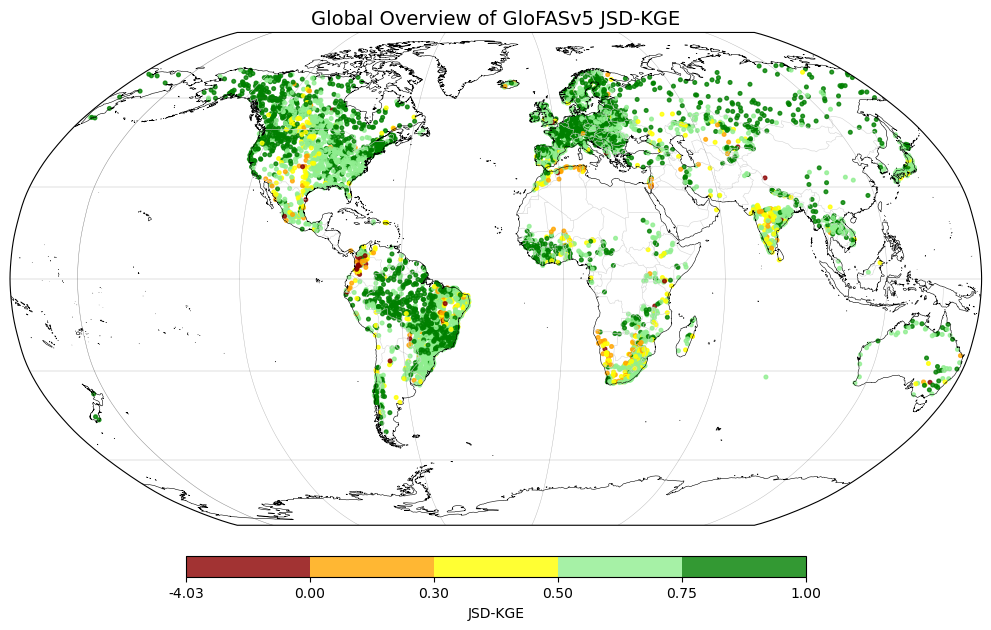

In [7]:
# Create figure with Robinson projection
from matplotlib.ticker import FormatStrFormatter

# Define KGE classes
boundaries = [glofas5_results.KGEmod.min(), 0, 0.3, 0.5, 0.75, 1]  # include negative values
colors = ["darkred", "orange", "yellow", "lightgreen", "green"]
cmap_discrete = ListedColormap(colors)
norm = BoundaryNorm(boundaries, ncolors=cmap_discrete.N)

fig, ax = plt.subplots(
    figsize=(16, 8),
    subplot_kw=dict(projection=ccrs.Robinson(central_longitude=-25))
)

# Add coastlines
coastline = cfeature.NaturalEarthFeature(
    'physical', 'coastline', '50m',
    edgecolor='black', facecolor='none', linewidth=0.4
)
ax.add_feature(coastline)
ax.add_feature(cfeature.BORDERS, edgecolor="lightgrey",linewidth = 0.4)

# Scatter plot of stations
sct = ax.scatter(
    glofas5_results.long,
    glofas5_results.lat,
    c=glofas5_results.KGEmod,
    s=7,                # small
    alpha=0.8,
    marker='o',
    cmap=cmap_discrete,
    norm=norm,
    transform=ccrs.PlateCarree()
)

# Horizontal colorbar
cbar = plt.colorbar(
    sct,
    shrink=0.5,
    aspect=30,
    orientation='horizontal',
    pad=0.05,
    label="JSD-KGE",
    # ticks=boundaries[1:-1]  # only internal ticks
)
cbar.ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# Add gridlines (no labels)
gridlines = ax.gridlines(draw_labels=False, linewidth=0.3, color='dimgray', alpha=0.5, linestyle='-')

# Global extent
ax.set_global()

# Title
ax.set_title("Global Overview of GloFASv5 JSD-KGE", fontsize=14)

plt.savefig(PATH_PLOT / 'map_modKGE_v5_global.jpg', dpi=300, bbox_inches='tight')


Text(0.5, 1.0, 'Global Overview of modKGE_v5')

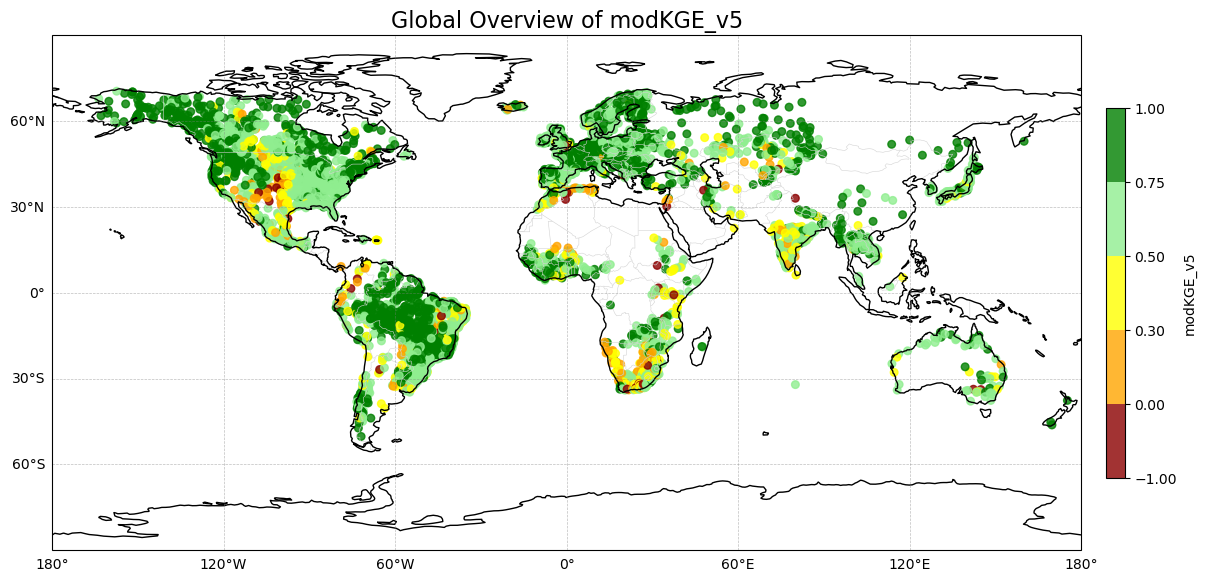

In [ ]:
# # Plot the Results
# # Define KGE bins and colors
# bins = [-1, 0, 0.3, 0.5, 0.75, 1]  # catch negative values
# colors = ["darkred", "orange", "yellow", "lightgreen", "green"]
# cmap = ListedColormap(colors)
# norm = BoundaryNorm(bins, ncolors=cmap.N)

# # Create figure with PlateCarree projection
# fig = plt.figure(figsize=(16, 8))
# ax = plt.axes(projection=ccrs.PlateCarree())

# # Add features
# ax.add_feature(cfeature.LAND, facecolor="white")
# # ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
# ax.add_feature(cfeature.BORDERS, edgecolor="lightgrey",linewidth = 0.4)
# ax.add_feature(cfeature.COASTLINE)

# # Scatter stations
# sc = ax.scatter(
#     glofas5_results["long"], 
#     glofas5_results["lat_x"], 
#     c=glofas5_results["modKGE_v5"], 
#     cmap=cmap, 
#     norm=norm,
#     s=30,
#     alpha=0.8,
#     transform=ccrs.PlateCarree()
# )

# # Add gridlines
# gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False

# # Add colorbar
# cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.6, pad=0.02)
# cbar.set_label("modKGE_v5")

# # Title
# ax.set_title("Global Overview of modKGE_v5", fontsize=16)